# Dimensionality Reduction Analysis

This notebook examines how much variance is retained as PCA components are added to each Waymo feature set:

- HOG
- HSV
- YOLO
- Road Geometry
- All Combined

The cumulative explained-variance plot is adapted from `plot_PCA` in `Exercise_09_Faces_Part1_Solution.ipynb`. The goal is to identify whether each feature vector can be replaced by a smaller set of PCA components while retaining most of its variance.

By default, the notebook analyzes the daytime-only `_v2` arrays. Set `USE_DAY_ONLY = False` in the setup cell to analyze the original day-and-night arrays instead.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except ImportError:
    display = print


# Allow the notebook to run from the project root or a notebooks folder.
current_dir = Path.cwd().resolve()

if (current_dir / 'data').exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / 'data').exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not find the data folder. Run this notebook from the project "
        "root or from a folder directly inside the project root."
    )

FEATURES_DIR = (
    PROJECT_ROOT / 'data' / 'processed' / 'waymo_e2e' / 'features'
)

# Analyze the daytime-only features by default.
USE_DAY_ONLY = True
FILE_SUFFIX = '_v2' if USE_DAY_ONLY else ''

# HOG and All Combined can have thousands of possible components.
# Increase this value if a desired variance threshold is not reached.
# Use None to calculate the full available PCA rank, which can be much slower.
MAX_COMPONENTS = 100
STANDARDIZE_FEATURES = True
RANDOM_STATE = 42

FEATURE_COLORS = {
    'HOG': '#d000c8',
    'HSV': '#00a6a6',
    'YOLO': '#ff7f0e',
    'Road Geometry': '#2ca02c',
    'All Combined': '#1f3bff',
}

print(f'Feature directory: {FEATURES_DIR}')
print(f'Dataset: {"daytime only (_v2)" if USE_DAY_ONLY else "all day + night"}')
print(f'Maximum plotted components: {MAX_COMPONENTS}')

Feature directory: C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\features
Dataset: daytime only (_v2)
Maximum plotted components: 100


## Load feature arrays

The arrays are loaded normally rather than as memory-mapped files. This avoids leaving `.npy` files locked on Windows after the notebook finishes.

In [2]:
feature_filenames = {
    'HOG': f'hog{FILE_SUFFIX}.npy',
    'HSV': f'hsv{FILE_SUFFIX}.npy',
    'YOLO': f'yolo{FILE_SUFFIX}.npy',
    'Road Geometry': f'road{FILE_SUFFIX}.npy',
}

label_filename = f'labels{FILE_SUFFIX}.npy'

missing_files = [
    filename
    for filename in list(feature_filenames.values()) + [label_filename]
    if not (FEATURES_DIR / filename).exists()
]

if missing_files:
    raise FileNotFoundError(
        'The following feature files are missing:\n  ' +
        '\n  '.join(missing_files)
    )

feature_sets = {
    name: np.load(FEATURES_DIR / filename)
    for name, filename in feature_filenames.items()
}
labels = np.load(
    FEATURES_DIR / label_filename,
    allow_pickle=True
).astype(str)

row_counts = {
    name: len(features)
    for name, features in feature_sets.items()
}

if len(set(row_counts.values())) != 1:
    raise ValueError(f'Feature arrays are not aligned: {row_counts}')

if next(iter(row_counts.values())) != len(labels):
    raise ValueError(
        f'Feature rows ({next(iter(row_counts.values()))}) do not match '
        f'label rows ({len(labels)}).'
    )

# Concatenate the four feature types in the same order used previously.
feature_sets['All Combined'] = np.concatenate([
    feature_sets['HOG'],
    feature_sets['HSV'],
    feature_sets['YOLO'],
    feature_sets['Road Geometry'],
], axis=1)

feature_shapes = pd.DataFrame([
    {
        'feature_set': name,
        'rows': features.shape[0],
        'original_dimensions': features.shape[1],
        'dtype': str(features.dtype),
    }
    for name, features in feature_sets.items()
])

display(feature_shapes)

,feature_set,rows,original_dimensions,dtype
0,HOG,1405,5796,float64
1,HSV,1405,34,float64
2,YOLO,1405,32,float32
3,Road Geometry,1405,8,float32
4,All Combined,1405,5870,float64


## PCA explained-variance functions

The course example calculates `np.cumsum(pca.explained_variance_ratio_)` for each feature matrix. The adapted version below adds:

- a dictionary of five named feature sets;
- optional feature standardization;
- a safe component limit for high-dimensional HOG;
- explicit component numbers beginning at 1;
- runtime and dimensionality metadata.

Standardization is enabled because the YOLO and road vectors contain measurements with different units and ranges. This also matches the preprocessing used in the earlier PCA visualization.

In [3]:
def get_PCA(
    feature_dict,
    max_components=100,
    standardize=True,
    random_state=42
):
    """
    Fit PCA separately to each feature set.

    Returns a dictionary containing the fitted PCA object, cumulative
    explained variance, and dimensionality information for each feature.
    """
    results = {}

    for name, features in feature_dict.items():
        start = time.time()

        # Use float32 to reduce memory use for HOG and All Combined.
        X = np.asarray(features, dtype=np.float32)
        n_samples, n_features = X.shape

        # Centering limits the maximum nonzero rank to n_samples - 1.
        maximum_rank = min(n_samples - 1, n_features)

        if max_components is None:
            n_components = maximum_rank
        else:
            n_components = min(max_components, maximum_rank)

        if standardize:
            scaler = StandardScaler()
            X_for_pca = scaler.fit_transform(X)
        else:
            scaler = None
            X_for_pca = X

        # Use exact PCA for small/full feature sets and randomized PCA
        # when only part of a high-dimensional feature set is requested.
        if n_components == maximum_rank:
            solver = 'full'
        else:
            solver = 'randomized'

        pca = PCA(
            n_components=n_components,
            svd_solver=solver,
            random_state=random_state
        )
        pca.fit(X_for_pca)

        cumulative_variance = np.cumsum(
            pca.explained_variance_ratio_
        )

        elapsed = time.time() - start

        results[name] = {
            'pca': pca,
            'scaler': scaler,
            'cumulative_variance': cumulative_variance,
            'n_samples': n_samples,
            'original_dimensions': n_features,
            'maximum_rank': maximum_rank,
            'fitted_components': n_components,
            'solver': solver,
            'elapsed_seconds': elapsed,
        }

        print(
            f'{name:<14} {n_components:>4} components, '
            f'{cumulative_variance[-1]:.1%} variance, '
            f'{elapsed:.1f} seconds'
        )

    return results


def plot_PCA(
    feature_dict,
    max_components=100,
    standardize=True,
    random_state=42,
    output_path=None
):
    """
    Plot cumulative explained variance against the number of components.

    This follows the plot_PCA function from the course faces notebook,
    expanded to support the five Waymo feature sets.
    """
    pca_results = get_PCA(
        feature_dict=feature_dict,
        max_components=max_components,
        standardize=standardize,
        random_state=random_state
    )

    plt.figure(figsize=(15, 6))

    largest_curve = max(
        result['fitted_components']
        for result in pca_results.values()
    )

    for name, result in pca_results.items():
        cumulative_variance = result['cumulative_variance']
        component_numbers = np.arange(1, len(cumulative_variance) + 1)

        plt.plot(
            component_numbers,
            cumulative_variance,
            color=FEATURE_COLORS[name],
            linewidth=2,
            label=name
        )

    # A 95% reference line provides a common dimensionality target.
    plt.axhline(
        0.95,
        color='black',
        linestyle='--',
        linewidth=1,
        alpha=0.7,
        label='95% variance'
    )

    tick_step = max(1, int(np.ceil(largest_curve / 20)))
    x_ticks = np.arange(1, largest_curve + 1, tick_step)

    if x_ticks[-1] != largest_curve:
        x_ticks = np.append(x_ticks, largest_curve)

    plt.xticks(x_ticks)
    plt.yticks(np.linspace(0, 1, 8))
    plt.xlim(1, largest_curve)
    plt.ylim(0, 1.01)
    plt.grid(True, alpha=0.65)
    plt.xlabel('Number of components')
    plt.ylabel('Cumulative explained variance')
    plt.title(
        'PCA Explained Variance by Number of Components\n'
        f'{"Daytime-only features" if USE_DAY_ONLY else "All day and night features"}'
    )
    plt.legend(loc='lower right')
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')

    plt.show()

    return pca_results

## Plot the cumulative explained-variance curves

For HOG and All Combined, the curve is initially limited to `MAX_COMPONENTS` for speed. HSV, YOLO, and Road Geometry use all available dimensions because they are smaller than this limit.

HOG             100 components, 49.6% variance, 0.4 seconds
HSV              34 components, 100.0% variance, 0.0 seconds
YOLO             32 components, 100.0% variance, 0.0 seconds
Road Geometry     8 components, 100.0% variance, 0.0 seconds
All Combined    100 components, 49.3% variance, 0.4 seconds


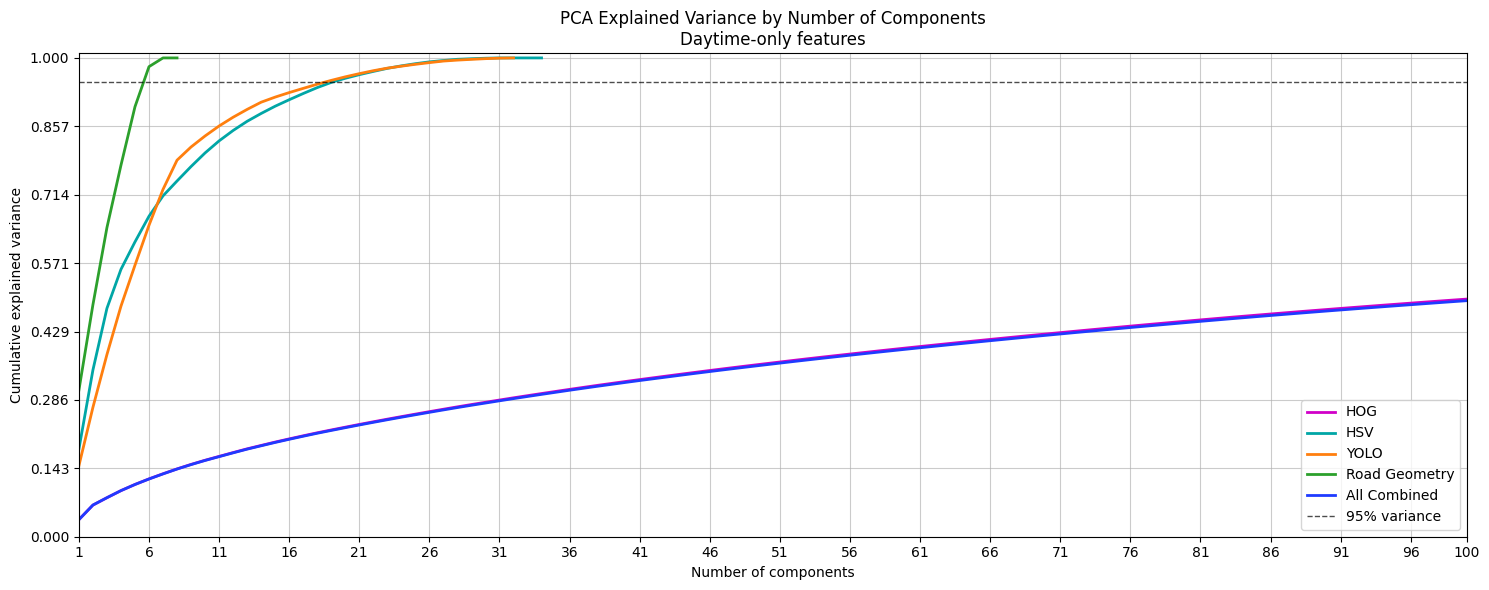

Saved plot to: C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\features\pca_explained_variance_curves_v2.png


In [4]:
plot_path = (
    FEATURES_DIR /
    f'pca_explained_variance_curves{FILE_SUFFIX}.png'
)

pca_results = plot_PCA(
    feature_dict=feature_sets,
    max_components=MAX_COMPONENTS,
    standardize=STANDARDIZE_FEATURES,
    random_state=RANDOM_STATE,
    output_path=plot_path
)

print(f'Saved plot to: {plot_path}')

## Components required at common variance thresholds

The table reports the smallest number of PCA components that reaches 90%, 95%, and 99% cumulative explained variance. If a threshold was not reached within `MAX_COMPONENTS`, the result is shown as `>100` (or the current limit).

`components_dropped_at_95pct` refers to replacing the original vector with PCA components. It does **not** identify specific original HOG bins, HSV bins, or YOLO fields to delete.

In [5]:
def components_for_threshold(cumulative_variance, threshold):
    """Return the first component count reaching a variance threshold."""
    index = np.searchsorted(cumulative_variance, threshold)

    if index < len(cumulative_variance):
        return int(index + 1)

    return None


summary_rows = []

for name, result in pca_results.items():
    cumulative_variance = result['cumulative_variance']

    row = {
        'feature_set': name,
        'original_dimensions': result['original_dimensions'],
        'maximum_training_rank': result['maximum_rank'],
        'components_calculated': result['fitted_components'],
        'variance_at_last_component': cumulative_variance[-1],
    }

    for threshold in [0.90, 0.95, 0.99]:
        threshold_label = int(threshold * 100)
        components = components_for_threshold(
            cumulative_variance,
            threshold
        )

        if components is None:
            row[f'components_for_{threshold_label}pct'] = (
                f'>{result["fitted_components"]}'
            )
        else:
            row[f'components_for_{threshold_label}pct'] = components

    components_95 = components_for_threshold(
        cumulative_variance,
        0.95
    )

    if components_95 is None:
        row['components_dropped_at_95pct'] = 'not determined'
        row['dimension_reduction_at_95pct'] = 'not determined'
    else:
        dropped = result['original_dimensions'] - components_95
        reduction = dropped / result['original_dimensions']
        row['components_dropped_at_95pct'] = dropped
        row['dimension_reduction_at_95pct'] = f'{reduction:.1%}'

    summary_rows.append(row)

pca_summary = pd.DataFrame(summary_rows)
pca_summary.to_csv(
    FEATURES_DIR / f'pca_dimensionality_summary{FILE_SUFFIX}.csv',
    index=False
)

summary_display = pca_summary.copy()
summary_display['variance_at_last_component'] = (
    summary_display['variance_at_last_component']
    .map(lambda value: f'{value:.1%}')
)

display(summary_display)

,feature_set,original_dimensions,maximum_training_rank,components_calculated,variance_at_last_component,components_for_90pct,components_for_95pct,components_for_99pct,components_dropped_at_95pct,dimension_reduction_at_95pct
0,HOG,5796,1404,100,49.6%,>100,>100,>100,not determined,not determined
1,HSV,34,34,34,100.0%,16,20,26,14,41.2%
2,YOLO,32,32,32,100.0%,14,19,26,13,40.6%
3,Road Geometry,8,8,8,100.0%,6,6,7,2,25.0%
4,All Combined,5870,1404,100,49.3%,>100,>100,>100,not determined,not determined


## Automatic interpretation

The statements below use 95% cumulative explained variance as the candidate retention threshold. A feature that does not reach 95% within the current component limit needs a larger `MAX_COMPONENTS` before its reducibility can be determined.

In [6]:
print('Candidate dimensionality at 95% explained variance:\n')

for name, result in pca_results.items():
    components_95 = components_for_threshold(
        result['cumulative_variance'],
        0.95
    )

    if components_95 is None:
        print(
            f'{name:<14} did not reach 95% within '
            f'{result["fitted_components"]} components. '
            'Increase MAX_COMPONENTS and rerun the PCA cells.'
        )
    else:
        original_dimensions = result['original_dimensions']
        components_dropped = original_dimensions - components_95
        reduction = components_dropped / original_dimensions

        print(
            f'{name:<14} keep {components_95} of '
            f'{original_dimensions} PCA dimensions; '
            f'drop {components_dropped} ({reduction:.1%}).'
        )

Candidate dimensionality at 95% explained variance:

HOG            did not reach 95% within 100 components. Increase MAX_COMPONENTS and rerun the PCA cells.
HSV            keep 20 of 34 PCA dimensions; drop 14 (41.2%).
YOLO           keep 19 of 32 PCA dimensions; drop 13 (40.6%).
Road Geometry  keep 6 of 8 PCA dimensions; drop 2 (25.0%).
All Combined   did not reach 95% within 100 components. Increase MAX_COMPONENTS and rerun the PCA cells.


## Interpretation cautions

- Explained variance measures information reconstruction, not classification performance. A low-variance component can still help distinguish a rare maneuver class.
- Before adopting a component count, place `StandardScaler` and `PCA(n_components=k)` inside the classification pipeline and confirm that accuracy, macro F1, and per-class recall remain acceptable.
- PCA components are combinations of the original dimensions. This analysis supports dropping transformed PCA components, not deleting individual raw feature columns.
- All Combined contains thousands of HOG dimensions. Even after per-column standardization, HOG contributes most of the combined vector's total variance because it contains far more columns than HSV, YOLO, or Road Geometry.
- The maximum useful PCA rank is bounded by the number of training examples minus one, even when the original feature vector has thousands of dimensions.
- If HOG or All Combined does not reach the desired threshold, increase `MAX_COMPONENTS` gradually—for example, from 100 to 250 or 500—rather than immediately calculating the full rank.